In [245]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data analysis, cleaning and visualisation

In [246]:
data = pd.read_csv('data/Fish.csv')
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
display(data.head())
display(data.describe())

Shape: (159, 7)
Columns: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [247]:
print("Sum of all Nan values for each column:")
data.isna().sum()

Sum of all Nan values for each column:


Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [248]:
print("Sum of entries for each species:")
data_sp = data.Species.value_counts()
data_sp.T

Sum of entries for each species:


Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

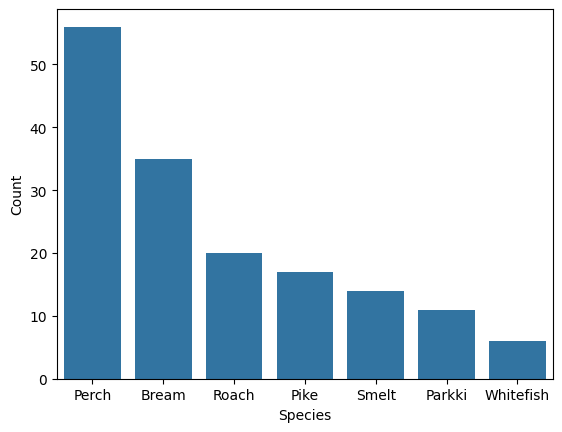

In [249]:
sns.barplot(x = data_sp.index, y = data_sp)
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [250]:
zero_weight_indices = data[data.Weight <= 0].index[0]
data.drop(index=zero_weight_indices, inplace=True)

In [251]:
print("Data shape after removing zero weight indices:", data.shape)

Data shape after removing zero weight indices: (158, 7)


In [252]:
# Correlation check 
# Veca korelacija izmedju nezavisnih promenljivih cini estimacije nepouzdanijim 
data.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915719,0.918603,0.923090,0.723857,0.886654
Length1,0.915719,1.000000,0.999516,0.992004,0.624409,0.866684
Length2,0.918603,0.999516,1.000000,0.994083,0.639503,0.873201
Length3,0.923090,0.992004,0.994083,1.000000,0.702655,0.878189
Height,0.723857,0.624409,0.639503,0.702655,1.000000,0.792401
Width,0.886654,0.866684,0.873201,0.878189,0.792401,1.000000


<Axes: >

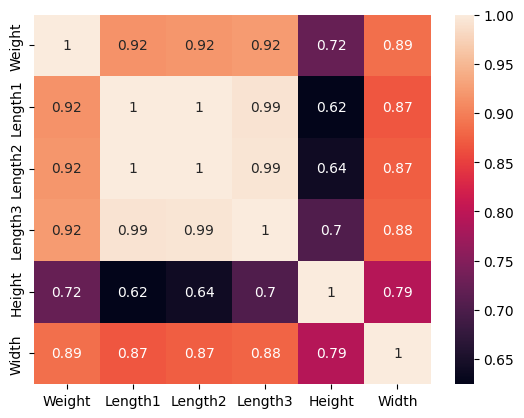

In [253]:
# Matrica korelacije 
sns.heatmap(data.corr(numeric_only=True), annot=True)

Length1, Length2 i Lenght3 imaju veliku korelaciju medjusobom, ali i sa ciljnom promenljivom Weight, pa bi bilo dobro zadrzati jednu od njih (umesto da izbacimo sve)

In [254]:
data.drop(columns=['Length2', 'Length3'], inplace=True)
data.rename(columns={"Length1":"Length"},inplace=True)
print("New shape:", data.shape)

New shape: (158, 5)


In [255]:
display(data.head())

,Species,Weight,Length,Height,Width
0,Bream,242.0,23.2,11.5200,4.0200
1,Bream,290.0,24.0,12.4800,4.3056
2,Bream,340.0,23.9,12.3778,4.6961
3,Bream,363.0,26.3,12.7300,4.4555
4,Bream,430.0,26.5,12.4440,5.1340


Text(0.5, 1.0, 'Outlier detection based on Weight')

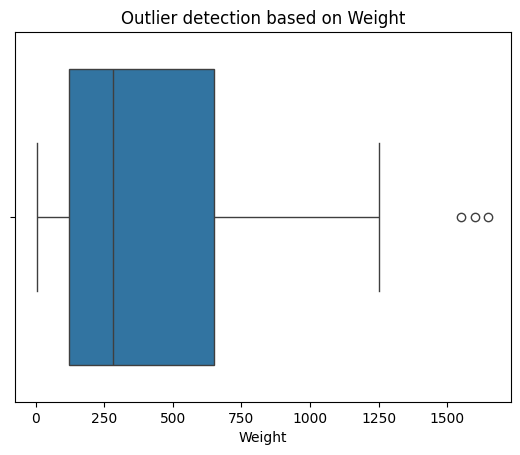

In [256]:
sns.boxplot(x = data['Weight'])
plt.title("Outlier detection based on Weight")

Text(0.5, 1.0, 'Outlier detection based on Length')

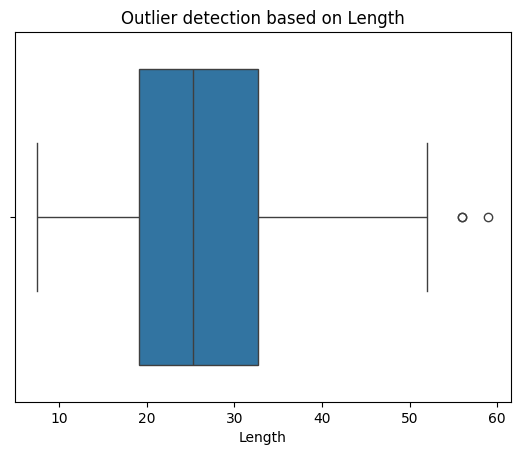

In [257]:
sns.boxplot(x = data['Length'])
plt.title("Outlier detection based on Length")

Text(0.5, 1.0, 'Outlier detection based on Height')

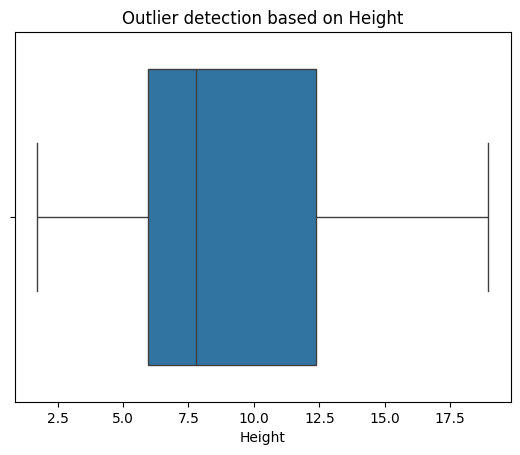

In [258]:
sns.boxplot(x = data['Height'])
plt.title("Outlier detection based on Height")

Text(0.5, 1.0, 'Outlier detection based on Width')

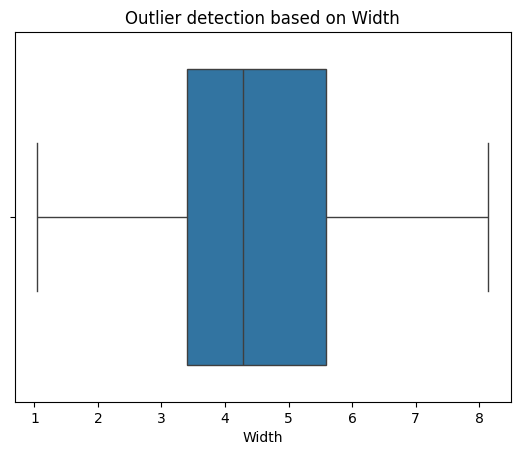

In [259]:
sns.boxplot(x = data['Width'])
plt.title("Outlier detection based on Width")

Nije dovoljno samo razmatrati pojedinacne kolone, jer individualne mere mogu izgledati normalno, ali njihove kombinacije mogu biti neobicne

In [260]:
# IQR on residuals
def outlier_detection(residuals):
    # abs_residuals = np.abs(residuals)
    Q1 = residuals.quantile(0.25)
    Q3 = residuals.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 
    return [(residuals < lower_bound) | (residuals > upper_bound), lower_bound, upper_bound]


In [261]:
X = data[["Length", "Width", "Height"]]
y = data["Weight"]
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

residuals = y - y_pred

outlier_mask, lower_bound, upper_bound = outlier_detection(residuals)

outliers = data[outlier_mask]

print("Number of outliers in original data bas on IQR on residuals:", len(outliers))
print(outliers)

Number of outliers in original data bas on IQR on residuals: 3
    Species  Weight  Length  Height  Width
142    Pike  1600.0    56.0   9.600  6.144
143    Pike  1550.0    56.0   9.600  6.144
144    Pike  1650.0    59.0  10.812  7.480


In [262]:
outlier_indices_weight, _, _ = outlier_detection(data["Weight"])
print("Outlier detection based on Weight:")
print(data[outlier_indices_weight])

Outlier detection based on Weight:
    Species  Weight  Length  Height  Width
142    Pike  1600.0    56.0   9.600  6.144
143    Pike  1550.0    56.0   9.600  6.144
144    Pike  1650.0    59.0  10.812  7.480


Ovo se poklapa sa boxplot grafikom.

Text(0.5, 1.0, 'Residual Plot')

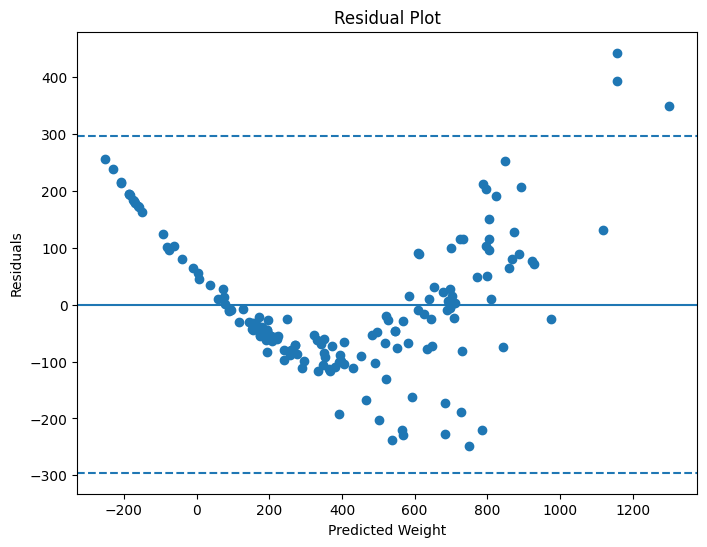

In [263]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(upper_bound, linestyle='--')
plt.axhline(lower_bound, linestyle='--')
plt.axhline(0)

plt.xlabel("Predicted Weight")
plt.ylabel("Residuals")
plt.title("Residual Plot")



Posto ispitujemo robusnost metoda, odudarajuce podatke necemo uklanjati. 

Kako je tezina direktno povezana sa zapreminom (tezina = zapremina * gustina), promenljiva Weight ne moze biti u linearnoj vezi za promenljivama koje predstavljaju dimenzije (Length_i, Height, Width). Shodno tome, vrsimo logaritamsku tranformaciju podataka. (Allometric relations)